## Reading the data

In [3]:
import pandas as pd
import numpy as np

In [4]:
historical_df = pd.read_csv("/content/historical_data.csv")
historical_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
sentiment_df = pd.read_csv("/content/fear_greed_index.csv")
sentiment_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
sentiment_df['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [7]:
historical_df['Account'].nunique()

32

In [8]:
trader_data = historical_df.copy()

In [9]:
trader_data['Timestamp IST'] = pd.to_datetime(trader_data['Timestamp IST'], errors='coerce')
trader_data = trader_data.dropna(subset=['Timestamp IST'])

In [10]:
trader_data['date'] = trader_data['Timestamp IST'].dt.normalize()
trader_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12


In [11]:
trader_data.isna().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


From the first glance, the dataset doesn't contains any missing values which is good for further analysis. Normalizing date helps to order the data according to date and the market conditions and traders activity according the day.

## Market Per-Day

In [12]:
daily_trades = trader_data.groupby('date').agg(
   total_pnl = ("Closed PnL", 'sum'),
   avg_pnl = ("Closed PnL", 'mean'),
   median_pnl = ("Closed PnL", 'median'),
   volataility = ("Closed PnL", lambda x: x.std()),
   total_volume_usd = ("Size USD", 'sum'),
   avg_trade_size = ("Size USD", 'mean'),
   num_trades = ("Trade ID", 'count'),
   active_accnts = ("Account", pd.Series.nunique),
   total_fee = ("Fee", 'sum'),
   executed_price = ("Execution Price", 'mean')
).sort_values("date", ascending=True).reset_index()

daily_trades

,date,total_pnl,avg_pnl,median_pnl,volataility,total_volume_usd,avg_trade_size,num_trades,active_accnts,total_fee,executed_price
0,2023-01-05,0.000000,0.000000,0.000000,0.000000,477.00,159.000000,3,1,0.000000,1898.133333
1,2023-05-12,0.000000,0.000000,0.000000,0.000000,50005.83,5556.203333,9,1,12.501455,11038.300000
2,2024-01-01,-129.531460,-7.196192,0.000000,85.847769,264239.53,14679.973889,18,1,66.059867,10373.330667
3,2024-01-02,0.000000,0.000000,0.000000,0.000000,2008.18,334.696667,6,1,0.502044,0.076126
4,2024-01-03,8244.241409,60.176945,27.043840,111.958609,472974.70,3452.370073,137,1,-0.546854,2.725657
...,...,...,...,...,...,...,...,...,...,...,...
183,2025-11-04,126406.479081,115.334379,0.000000,1053.703425,11319327.07,10327.853166,1096,16,2174.439078,18896.037772
184,2025-12-01,5742.241803,9.538608,0.723320,150.463661,2258459.17,3751.593306,602,7,612.082753,12893.280710
185,2025-12-02,19848.635032,19.251828,0.000000,351.502794,4143974.54,4019.373948,1031,12,1099.155031,20122.266070
186,2025-12-03,288105.984215,72.607355,1.606006,541.102189,18618139.15,4692.071358,3968,13,3658.413572,4000.649117


## Account per day

In [13]:
accnt_day = trader_data.groupby(['Account', 'date']).agg(
    accnt_pnl = ("Closed PnL", 'sum'),
    accnt_num_trades = ("Trade ID", 'count'),
    accnt_trade_size = ("Size USD", 'sum')
).reset_index()

accnt_day

,Account,date,accnt_pnl,accnt_num_trades,accnt_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,33,1212299.96
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,177,900880.13
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,45,134360.89
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,10,1858470.00
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,839,19794543.66
...,...,...,...,...,...
902,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-11-03,-136.417418,333,408130.63
903,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-11-04,857.602940,123,164913.23
904,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-12-02,1747.189909,71,115270.92
905,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-12-03,8096.937709,553,990831.72


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

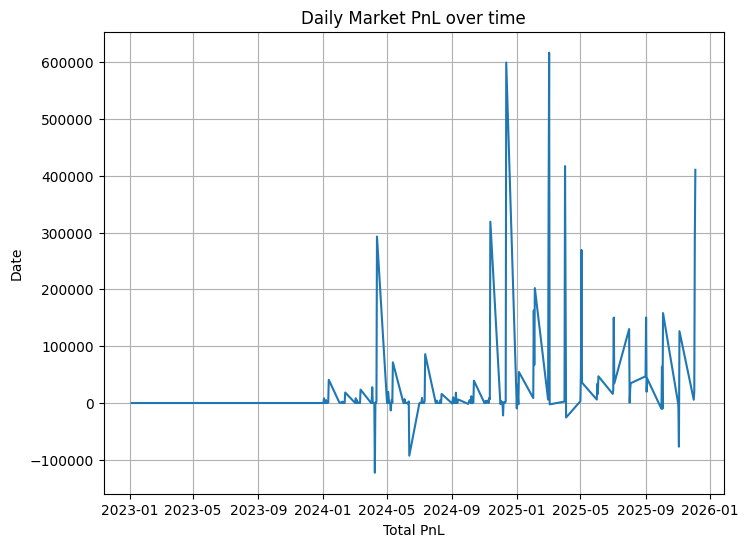

In [15]:
plt.figure(figsize=(8,6))
plt.plot(daily_trades['date'], daily_trades['total_pnl'])
plt.title("Daily Market PnL over time")
plt.xlabel("Total PnL")
plt.ylabel("Date")
plt.grid(True)
plt.savefig("Daily_PnL_time.png")
plt.show()

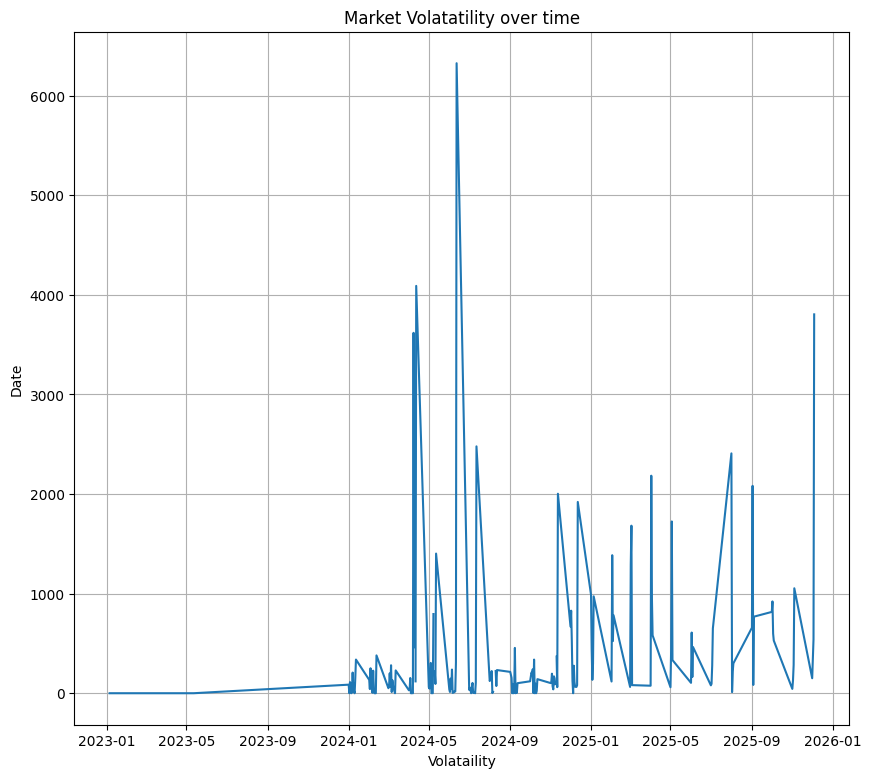

In [16]:
plt.figure(figsize=(10,9))
plt.plot(daily_trades['date'], daily_trades['volataility'])
plt.title("Market Volatatility over time")
plt.xlabel("Volataility")
plt.ylabel("Date")
plt.grid(True)
plt.savefig("volatile_time.png")
plt.show()

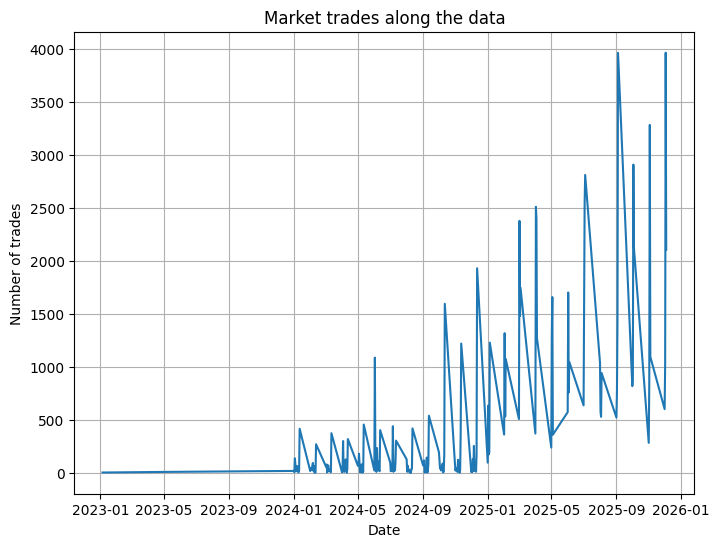

In [17]:
plt.figure(figsize=(8,6))
plt.plot(daily_trades['date'], daily_trades['num_trades'])
plt.title("Market trades along the data")
plt.xlabel("Date")
plt.ylabel("Number of trades")
plt.grid(True)
plt.savefig("num_trades.png")
plt.show()

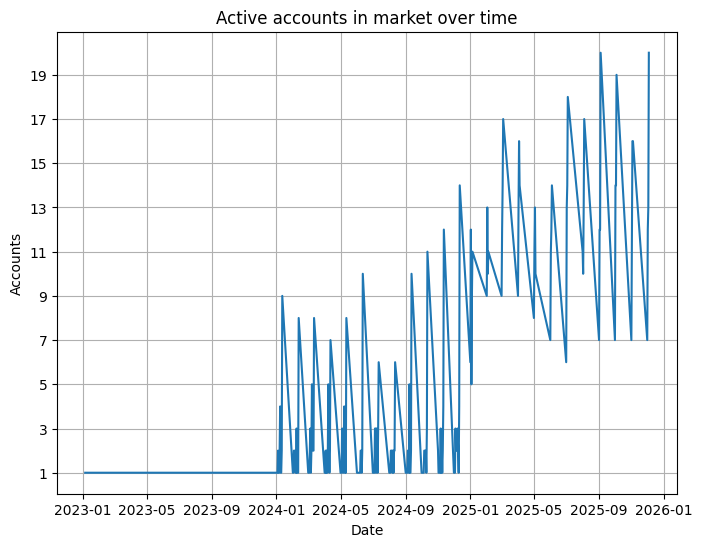

In [18]:
plt.figure(figsize=(8,6))
plt.plot(daily_trades['date'], daily_trades['active_accnts'])
plt.title("Active accounts in market over time")
plt.xlabel("Date")
plt.ylabel("Accounts")
plt.yticks(range(1,21,2))
plt.grid(True)
plt.savefig("act_accnts.png")
plt.show()

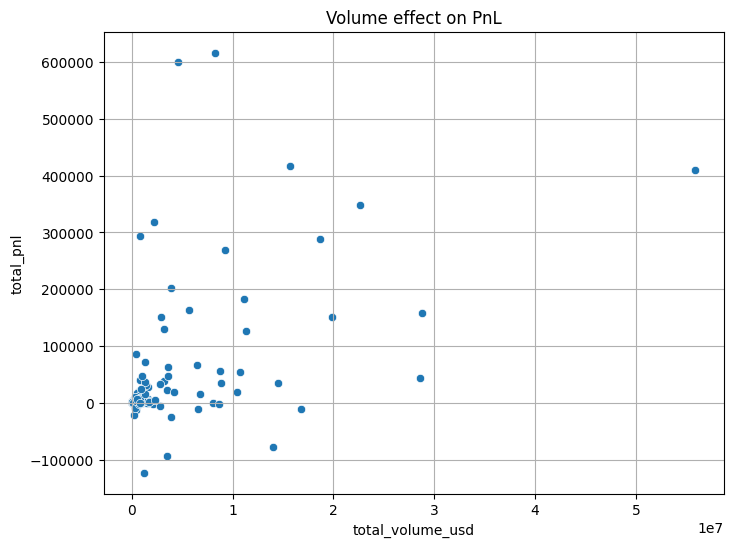

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='total_volume_usd', y='total_pnl', data=daily_trades)
plt.title("Volume effect on PnL")
plt.grid(True)
plt.savefig("volume_pnl.png")
plt.show()

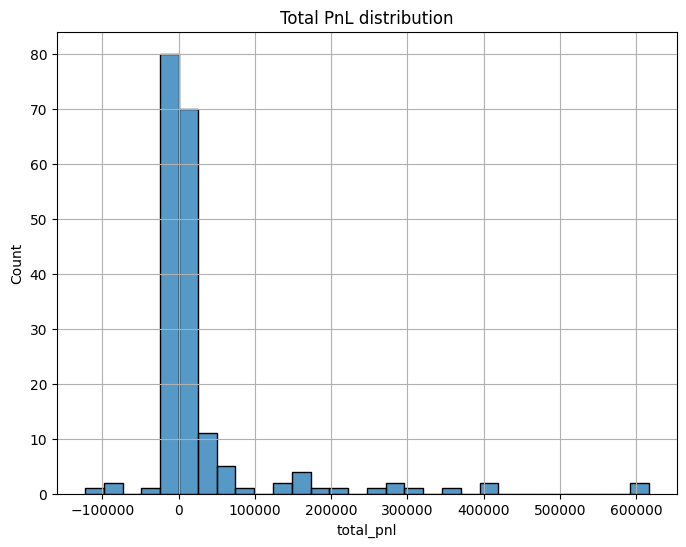

In [20]:
plt.figure(figsize=(8,6))
sns.histplot(daily_trades['total_pnl'], bins=30)
plt.title("Total PnL distribution")
plt.grid(True)
plt.savefig("total_PnL_distribution.png")
plt.show()

From the intial checks and analysis, the daily trades along pnl has some zeros in place, it indicates that the market closed on those days with 0 loss and win. The volataility shows in some days there are high volatile trends in middle months of 2024 to early 2025. The number of trades along the date shows some devaitions in number of trades, especially high trades in months of jan to may of 2025. When checking with accounts active in market, shows small similar behaviour with number of trades and active accounts in market as more active accounts results in more trades. The total volume and pnl actually doesn't gave a relationship as more volume more pnl, nothing like that. But too the data clustered around early small point than large volume. The distribution of total PnL shows there is large peak in 0 and left tail.

The next step can be done as to normalize the data to find better correlations and relationships.

In [21]:
df_sent = sentiment_df[['date', 'classification', 'value']].copy()
df_sent['date'] = pd.to_datetime(df_sent['date'])
df_sent

,date,classification,value
0,2018-02-01,Fear,30
1,2018-02-02,Extreme Fear,15
2,2018-02-03,Fear,40
3,2018-02-04,Extreme Fear,24
4,2018-02-05,Extreme Fear,11
...,...,...,...
2639,2025-04-28,Neutral,54
2640,2025-04-29,Greed,60
2641,2025-04-30,Greed,56
2642,2025-05-01,Neutral,53


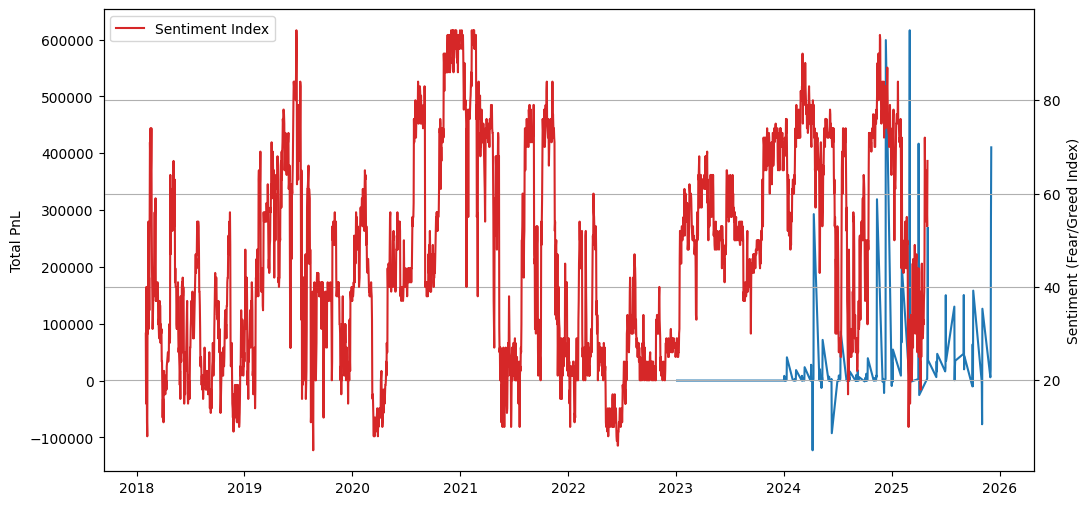

In [22]:
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(daily_trades['date'], daily_trades['total_pnl'], color='tab:blue', label='Total PnL')
ax2 = ax1.twinx()
ax2.plot(df_sent['date'], df_sent['value'], color='tab:red', label='Sentiment Index')

ax1.set_ylabel("Total PnL")
ax2.set_ylabel("Sentiment (Fear/Greed Index)")

plt.grid(True)
plt.legend()
plt.show()

In [23]:

merged = pd.merge_asof(daily_trades.sort_values('date'),
                       df_sent.sort_values('date'),
                       on='date', direction='backward')


merged[['total_pnl', 'volataility', 'value']].corr()

,total_pnl,volataility,value
total_pnl,1.000000,0.474607,-0.022134
volataility,0.474607,1.000000,0.080220
value,-0.022134,0.080220,1.000000


In [24]:
merged['sentiment_shift1'] = merged['value'].shift(1)
merged[['total_pnl', 'sentiment_shift1']].corr()

,total_pnl,sentiment_shift1
total_pnl,1.000000,-0.081984
sentiment_shift1,-0.081984,1.000000


When checking with both, i found that the sentiment dataset has more data with dates that don't exist in trade data. Merged and checked between sentiment dataset and trader dataset for the correlation between features. Took the shifting lags with one day and computed the correlation. The correlation found to be negative.

The next step that is to do is normalize and check for the analysis again and that may allow the relationship clear. The date range mismatch should also be cleared too.

## Diving into overlapping date ranges

In [25]:
trader_data['Timestamp IST'] = pd.to_datetime(trader_data['Timestamp IST'], errors='coerce')
trader_data = trader_data.dropna(subset=['Timestamp IST'])
trader_data['date'] = trader_data['Timestamp IST'].dt.normalize()
trader_data = trader_data.drop(columns='Timestamp IST')
trader_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12


In [26]:
df_sent = sentiment_df.copy()
df_sent['date'] = pd.to_datetime(df_sent['date'], errors='coerce').dt.normalize()
df_sent = df_sent.dropna(subset=['date'])
df_sent.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [27]:
start = max(trader_data['date'].min(), df_sent['date'].min())
end = min(trader_data['date'].max(), df_sent['date'].max())

end

Timestamp('2025-05-02 00:00:00')

In [28]:
trad = trader_data[(trader_data['date'] >= start) & (trader_data['date'] <= end)]
sent = df_sent[(df_sent['date'] >= start) & (df_sent['date'] <= end)]

In [29]:
daily_trades = trad.groupby('date').agg(
    total_pnl = ('Closed PnL','sum'),
    mean_pnl  = ('Closed PnL','mean'),
    median_pnl= ('Closed PnL','median'),
    volatility = ('Closed PnL', lambda x: x.std()),
    total_volume_usd = ('Size USD','sum'),
    avg_trade_size_usd = ('Size USD','mean'),
    num_trades = ('Trade ID','count'),
    active_accounts = ('Account', pd.Series.nunique),
    total_fee = ('Fee','sum')
).reset_index()

daily_trades.head()

,date,total_pnl,mean_pnl,median_pnl,volatility,total_volume_usd,avg_trade_size_usd,num_trades,active_accounts,total_fee
0,2023-01-05,0.000000,0.000000,0.00000,0.000000,477.00,159.000000,3,1,0.000000
1,2023-05-12,0.000000,0.000000,0.00000,0.000000,50005.83,5556.203333,9,1,12.501455
2,2024-01-01,-129.531460,-7.196192,0.00000,85.847769,264239.53,14679.973889,18,1,66.059867
3,2024-01-02,0.000000,0.000000,0.00000,0.000000,2008.18,334.696667,6,1,0.502044
4,2024-01-03,8244.241409,60.176945,27.04384,111.958609,472974.70,3452.370073,137,1,-0.546854


In [30]:
daily_trades['total_pnl'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,total_pnl
count,158.000000
mean,22941.825756
std,90851.081811
min,-122672.000883
1%,-54372.533876
5%,-1967.090507
25%,0.000000
50%,460.306586
75%,5172.042387
95%,165737.880667


In [31]:
from scipy.stats.mstats import winsorize
daily_trades['pnl_wins'] = winsorize(daily_trades['total_pnl'], limits=[0.05, 0.05])

daily_trades.head()

,date,total_pnl,mean_pnl,median_pnl,volatility,total_volume_usd,avg_trade_size_usd,num_trades,active_accounts,total_fee,pnl_wins
0,2023-01-05,0.000000,0.000000,0.00000,0.000000,477.00,159.000000,3,1,0.000000,0.000000
1,2023-05-12,0.000000,0.000000,0.00000,0.000000,50005.83,5556.203333,9,1,12.501455,0.000000
2,2024-01-01,-129.531460,-7.196192,0.00000,85.847769,264239.53,14679.973889,18,1,66.059867,-129.531460
3,2024-01-02,0.000000,0.000000,0.00000,0.000000,2008.18,334.696667,6,1,0.502044,0.000000
4,2024-01-03,8244.241409,60.176945,27.04384,111.958609,472974.70,3452.370073,137,1,-0.546854,8244.241409


In [32]:
daily_trades['log volume'] = np.log1p(daily_trades['total_volume_usd'])
daily_trades

,date,total_pnl,mean_pnl,median_pnl,volatility,total_volume_usd,avg_trade_size_usd,num_trades,active_accounts,total_fee,pnl_wins,log volume
0,2023-01-05,0.000000,0.000000,0.00000,0.000000,477.00,159.000000,3,1,0.000000,0.000000,6.169611
1,2023-05-12,0.000000,0.000000,0.00000,0.000000,50005.83,5556.203333,9,1,12.501455,0.000000,10.819915
2,2024-01-01,-129.531460,-7.196192,0.00000,85.847769,264239.53,14679.973889,18,1,66.059867,-129.531460,12.484615
3,2024-01-02,0.000000,0.000000,0.00000,0.000000,2008.18,334.696667,6,1,0.502044,0.000000,7.605482
4,2024-01-03,8244.241409,60.176945,27.04384,111.958609,472974.70,3452.370073,137,1,-0.546854,8244.241409,13.066799
...,...,...,...,...,...,...,...,...,...,...,...,...
153,2025-04-02,416876.888120,165.954175,0.00000,2184.168235,15678409.27,6241.404964,2512,13,3853.778564,182075.566585,16.567795
154,2025-04-03,182075.566585,75.801651,0.00000,940.953835,11124247.15,4631.243609,2402,16,2220.336485,182075.566585,16.224638
155,2025-04-04,-25515.678950,-20.059496,0.00000,581.263921,3835545.73,3015.366140,1272,14,836.063409,-2202.662242,15.159823
156,2025-05-01,3187.719363,13.337738,0.00000,59.881874,451943.57,1890.977280,239,8,139.341611,3187.719363,13.021315


In [33]:
traders = daily_trades.set_index('date').sort_index()
sentiments = sent.set_index('date').sort_index()

weekly_pnl_trad = traders['total_pnl'].resample('W').sum()
weekly_pnl_sent = sentiments['value'].resample('W').mean()

weekly_pnl_sent

,value
date,
2023-01-08,26.250000
2023-01-15,33.714286
2023-01-22,50.000000
2023-01-29,52.714286
2023-02-05,57.714286
...,...
2025-04-06,32.714286
2025-04-13,31.000000
2025-04-20,32.857143


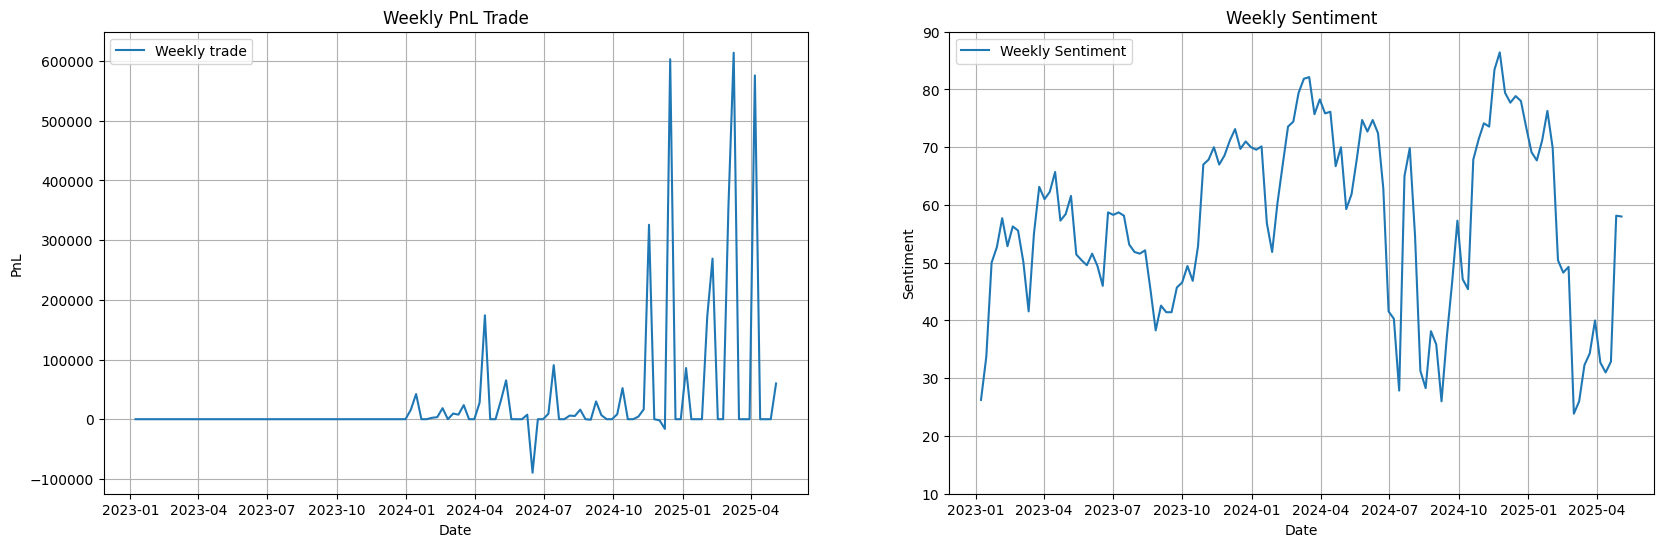

In [34]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(weekly_pnl_trad, label='Weekly trade')
plt.title("Weekly PnL Trade")
plt.xlabel("Date")
plt.ylabel("PnL")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(weekly_pnl_sent, label='Weekly Sentiment')
plt.title("Weekly Sentiment")
plt.xlabel("Date")
plt.ylabel("Sentiment")
plt.yticks(range(10,100,10))
plt.legend()
plt.grid(True)

plt.show()

Combined the overlapped dates of two datasets and checked if there is similarity in pnl and sentiment score. Sentiment Scores are waving up and down irrespective of a trend. The market sometimes drives the sentiments, but that is not sure.

Furthur checking if there is a linear relationship exist between them

In [35]:
traders['pnl_7d'] = traders['total_pnl'].rolling(7).sum()
sentiments['pnl_7d'] = sentiments['value'].rolling(7).mean()

traders

,total_pnl,mean_pnl,median_pnl,volatility,total_volume_usd,avg_trade_size_usd,num_trades,active_accounts,total_fee,pnl_wins,log volume,pnl_7d
date,,,,,,,,,,,,
2023-01-05,0.000000,0.000000,0.00000,0.000000,477.00,159.000000,3,1,0.000000,0.000000,6.169611,NaN
2023-05-12,0.000000,0.000000,0.00000,0.000000,50005.83,5556.203333,9,1,12.501455,0.000000,10.819915,NaN
2024-01-01,-129.531460,-7.196192,0.00000,85.847769,264239.53,14679.973889,18,1,66.059867,-129.531460,12.484615,NaN
2024-01-02,0.000000,0.000000,0.00000,0.000000,2008.18,334.696667,6,1,0.502044,0.000000,7.605482,NaN
2024-01-03,8244.241409,60.176945,27.04384,111.958609,472974.70,3452.370073,137,1,-0.546854,8244.241409,13.066799,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-02,416876.888120,165.954175,0.00000,2184.168235,15678409.27,6241.404964,2512,13,3853.778564,182075.566585,16.567795,1.590590e+06
2025-04-03,182075.566585,75.801651,0.00000,940.953835,11124247.15,4631.243609,2402,16,2220.336485,182075.566585,16.224638,1.570453e+06
2025-04-04,-25515.678950,-20.059496,0.00000,581.263921,3835545.73,3015.366140,1272,14,836.063409,-2202.662242,15.159823,1.538909e+06


In [36]:
traders['total_pnl']

,total_pnl
date,
2023-01-05,0.000000
2023-05-12,0.000000
2024-01-01,-129.531460
2024-01-02,0.000000
2024-01-03,8244.241409
...,...
2025-04-02,416876.888120
2025-04-03,182075.566585
2025-04-04,-25515.678950


In [37]:
median = np.median(traders['total_pnl'])
mad = np.median(np.abs(traders['total_pnl'] - np.median(traders['total_pnl'])))
traders['pnl_robust_z'] = (traders['total_pnl'] - median) / (mad + 1e-9)

traders

,total_pnl,mean_pnl,median_pnl,volatility,total_volume_usd,avg_trade_size_usd,num_trades,active_accounts,total_fee,pnl_wins,log volume,pnl_7d,pnl_robust_z
date,,,,,,,,,,,,,
2023-01-05,0.000000,0.000000,0.00000,0.000000,477.00,159.000000,3,1,0.000000,0.000000,6.169611,NaN,-0.770184
2023-05-12,0.000000,0.000000,0.00000,0.000000,50005.83,5556.203333,9,1,12.501455,0.000000,10.819915,NaN,-0.770184
2024-01-01,-129.531460,-7.196192,0.00000,85.847769,264239.53,14679.973889,18,1,66.059867,-129.531460,12.484615,NaN,-0.986915
2024-01-02,0.000000,0.000000,0.00000,0.000000,2008.18,334.696667,6,1,0.502044,0.000000,7.605482,NaN,-0.770184
2024-01-03,8244.241409,60.176945,27.04384,111.958609,472974.70,3452.370073,137,1,-0.546854,8244.241409,13.066799,NaN,13.024056
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-02,416876.888120,165.954175,0.00000,2184.168235,15678409.27,6241.404964,2512,13,3853.778564,182075.566585,16.567795,1.590590e+06,696.746928
2025-04-03,182075.566585,75.801651,0.00000,940.953835,11124247.15,4631.243609,2402,16,2220.336485,182075.566585,16.224638,1.570453e+06,303.878088
2025-04-04,-25515.678950,-20.059496,0.00000,581.263921,3835545.73,3015.366140,1272,14,836.063409,-2202.662242,15.159823,1.538909e+06,-43.462938


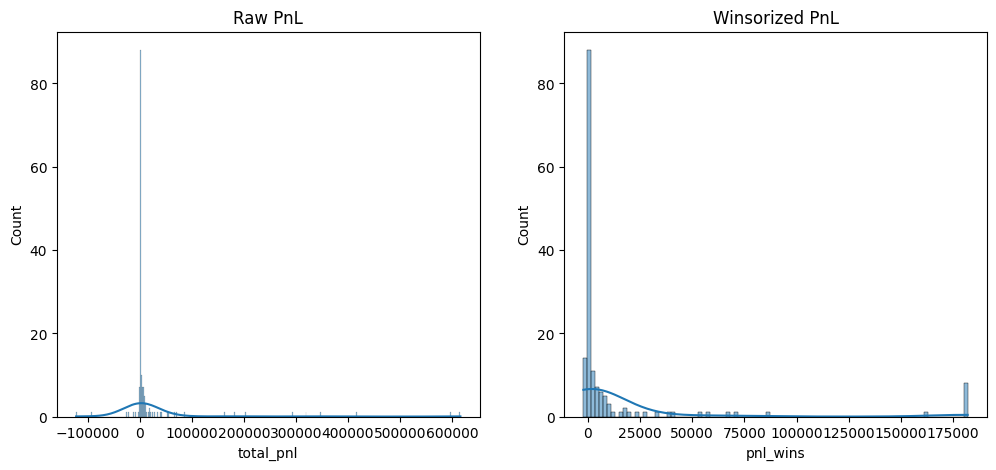

In [38]:
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.histplot(traders['total_pnl'], kde=True, ax=axes[0])
sns.histplot(traders['pnl_wins'], kde=True, ax=axes[1])
axes[0].set_title("Raw PnL")
axes[1].set_title("Winsorized PnL")
plt.savefig("raw_winsorized_pnl.png")
plt.show()

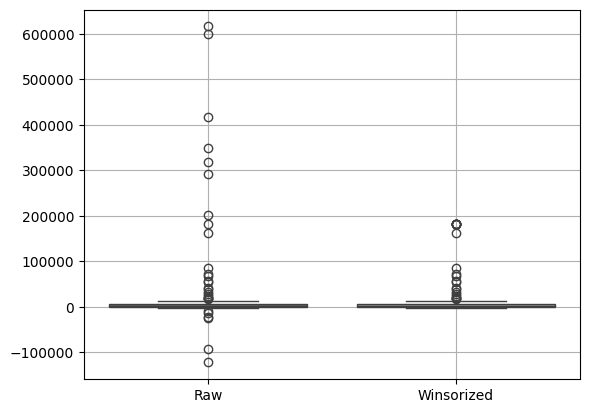

In [39]:
sns.boxplot(data=[traders['total_pnl'], traders['pnl_wins']])
plt.xticks([0,1], ['Raw', 'Winsorized'])
plt.grid(True)
plt.savefig("Raw_winsorized_boxplot.png")
plt.show()

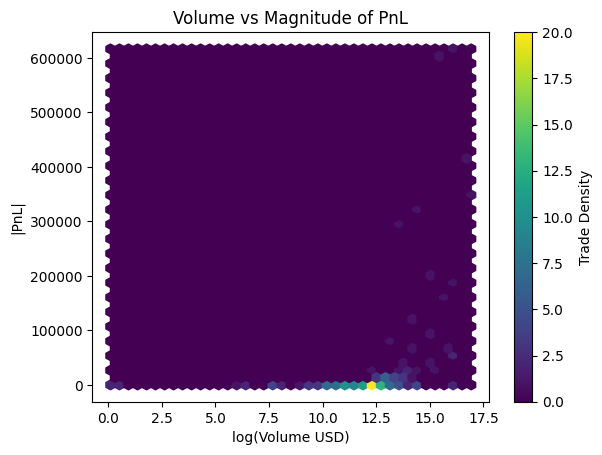

In [40]:
plt.hexbin(traders['log volume'], np.abs(traders['total_pnl']), gridsize=40, cmap='viridis')
plt.xlabel("log(Volume USD)")
plt.ylabel("|PnL|")
plt.title("Volume vs Magnitude of PnL")
plt.colorbar(label='Trade Density')
plt.savefig("hexplot_volume_pnl.png")
plt.show()

From being normalized the volume with log transform to make the outliers handle well. Made the traders data and sentiment data with proper dates. When inspecting, i found there is overlapp of dates. The sentiment dataset has previous dates than traders data. So i managed to take the datas with same date for inspecting. Using the volume log transformed, managed to get the fact that more volume has more total pnl irrespective of direction. The hexplot shows the density blobs within that high regions.

The raw pnl and winsorized pnl with limit at 5% first and 5% last gets a valid analysis. The more deviations is prevented by winsorization. So when inspecting the outliers are few in winsorized while outliers are larger in raw.

## Cross checking

In [41]:
sentiment_map = {
    'Extreme Fear': -2,
    'Fear': -1,
    'Neutral': 0,
    'Greed': 1,
    'Extreme Greed': 2
}

sentiments['sentiment_score'] = sentiments['classification'].map(sentiment_map)
sentiments

,timestamp,value,classification,pnl_7d,sentiment_score
date,,,,,
2023-01-05,1672896600,29,Fear,NaN,-1
2023-01-06,1672983000,26,Fear,NaN,-1
2023-01-07,1673069400,25,Fear,NaN,-1
2023-01-08,1673155800,25,Fear,NaN,-1
2023-01-09,1673242200,25,Fear,NaN,-1
...,...,...,...,...,...
2025-04-28,1745818200,54,Neutral,60.285714,0
2025-04-29,1745904600,60,Greed,62.142857,1
2025-04-30,1745991000,56,Greed,59.857143,1


In [42]:
df_sentiment = sentiments.drop(columns=['classification', 'pnl_7d']).resample('D').mean().ffill()
merged = traders.merge(df_sentiment, how='left', left_index=True, right_index=True)
merged

,total_pnl,mean_pnl,median_pnl,volatility,total_volume_usd,avg_trade_size_usd,num_trades,active_accounts,total_fee,pnl_wins,log volume,pnl_7d,pnl_robust_z,timestamp,value,sentiment_score
date,,,,,,,,,,,,,,,,
2023-01-05,0.000000,0.000000,0.00000,0.000000,477.00,159.000000,3,1,0.000000,0.000000,6.169611,NaN,-0.770184,1.672897e+09,29.0,-1.0
2023-05-12,0.000000,0.000000,0.00000,0.000000,50005.83,5556.203333,9,1,12.501455,0.000000,10.819915,NaN,-0.770184,1.683869e+09,49.0,0.0
2024-01-01,-129.531460,-7.196192,0.00000,85.847769,264239.53,14679.973889,18,1,66.059867,-129.531460,12.484615,NaN,-0.986915,1.704087e+09,65.0,1.0
2024-01-02,0.000000,0.000000,0.00000,0.000000,2008.18,334.696667,6,1,0.502044,0.000000,7.605482,NaN,-0.770184,1.704173e+09,71.0,1.0
2024-01-03,8244.241409,60.176945,27.04384,111.958609,472974.70,3452.370073,137,1,-0.546854,8244.241409,13.066799,NaN,13.024056,1.704260e+09,70.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-02,416876.888120,165.954175,0.00000,2184.168235,15678409.27,6241.404964,2512,13,3853.778564,182075.566585,16.567795,1.590590e+06,696.746928,1.743572e+09,44.0,-1.0
2025-04-03,182075.566585,75.801651,0.00000,940.953835,11124247.15,4631.243609,2402,16,2220.336485,182075.566585,16.224638,1.570453e+06,303.878088,1.743658e+09,25.0,-1.0
2025-04-04,-25515.678950,-20.059496,0.00000,581.263921,3835545.73,3015.366140,1272,14,836.063409,-2202.662242,15.159823,1.538909e+06,-43.462938,1.743745e+09,28.0,-1.0


In [43]:
merged[['total_pnl', 'sentiment_score']].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 158 entries, 2023-01-05 to 2025-05-02
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   total_pnl        158 non-null    float64
 1   sentiment_score  158 non-null    float64
dtypes: float64(2)
memory usage: 3.7 KB


In [44]:
merged[['total_pnl', 'sentiment_score']].head()

,total_pnl,sentiment_score
date,,
2023-01-05,0.000000,-1.0
2023-05-12,0.000000,0.0
2024-01-01,-129.531460,1.0
2024-01-02,0.000000,1.0
2024-01-03,8244.241409,1.0


## Correlation check

In [51]:
merged[['total_pnl', 'sentiment_score']].corr()

,total_pnl,sentiment_score
total_pnl,1.000000,-0.057291
sentiment_score,-0.057291,1.000000


<Figure size 1000x700 with 0 Axes>

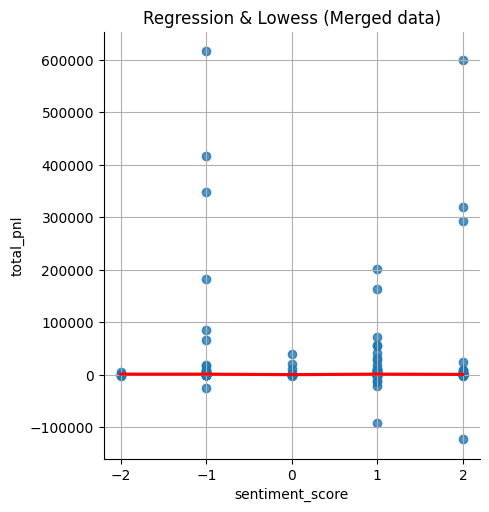

In [48]:
plt.figure(figsize=(10,7))
sns.lmplot(data=merged, x='sentiment_score', y='total_pnl', lowess=True, line_kws={'color':'red'})
plt.title("Regression & Lowess (Merged data)")
plt.xticks(range(-2,3,1))
plt.grid(True)
plt.savefig("regression_lowess.png")
plt.show()

The Lowess and regression plots of sentiment_score vs total_pnl:

Regression line near zero is  weak linear relation.

Few positive and negative deviations, suggests nonlinear or regime-dependent relationship.

Traders may profit in both extremes (contrarian behavior).

In [52]:
merged[['total_pnl', 'sentiment_score']].corr(method='spearman')

,total_pnl,sentiment_score
total_pnl,1.000000,-0.022121
sentiment_score,-0.022121,1.000000


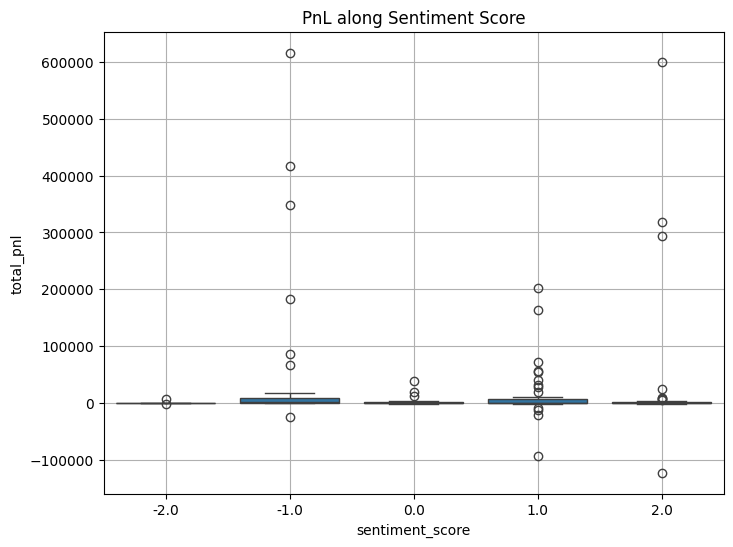

In [55]:
plt.figure(figsize=(8,6))
sns.boxplot(x='sentiment_score', y='total_pnl', data=merged)
plt.title("PnL along Sentiment Score")
plt.grid(True)
plt.show()

In [56]:
for lag in range(-5, 6):
    corr = merged['sentiment_score'].shift(lag).corr(merged['total_pnl'])
    print(lag, corr)

-5 -0.08818165503840326
-4 -0.09009530097934325
-3 -0.13091393743741503
-2 -0.1663732995301011
-1 -0.19561691140438908
0 -0.0572910814876306
1 -0.1355601015519317
2 -0.07734531911943035
3 0.0013847432135030218
4 -0.012076641921875467
5 0.0003150822256452029


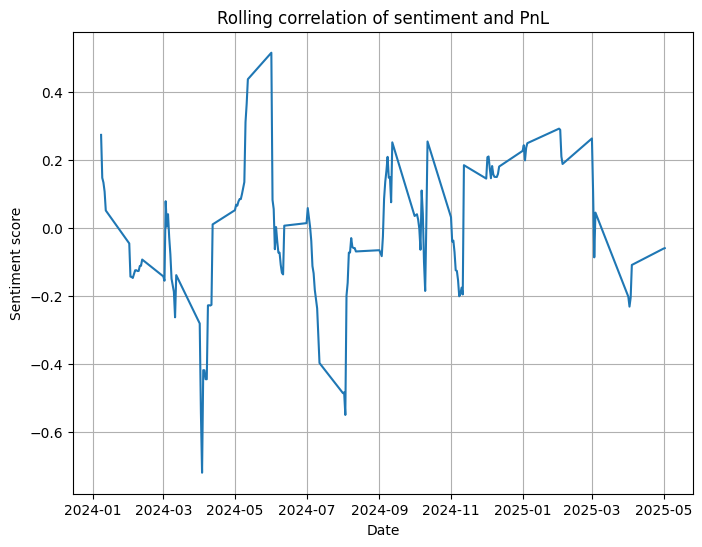

In [85]:
rolling_correlation = merged['sentiment_score'].rolling(14, min_periods=10).corr(merged['total_pnl'])

plt.figure(figsize=(8,6))
plt.plot(rolling_correlation.dropna())
plt.title("Rolling correlation of sentiment and PnL")
plt.xlabel("Date")
plt.ylabel("Sentiment score")
plt.grid(True)
plt.savefig("Rolling_correlation.png")
plt.show()


When checking boxplot with sentiment classes, the extreme fear lies on 0 as may be in extreme fear traders fear to trade. When looking most of the classes has stability. In fear and greed there is slight deviation compared to others. The extreme greed also stabilized but it also shows there is heavy loss when the greed matters and also there is high profit too.

From the rolling correlation with 14 days and time period with 10 it is found the values betweem -0.6 to 0.5. In 2024-05 and around there is trend that traders has more PnL when market is greedy sentiment and also in 2024 3rd month around negative correlation as the market sentiment not fitted well.
